In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sentiment_data = pd.read_csv("data/fear_greed_index.csv")
sentiment_data.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trader_data = pd.read_csv("data/historical_data.csv", on_bad_lines='skip')
trader_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
print(trader_data.columns)
print(sentiment_data.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [6]:
trader_data.columns = trader_data.columns.str.strip().str.lower().str.replace(" ", "_")
sentiment_data.columns = sentiment_data.columns.str.strip().str.lower().str.replace(" ", "_")

In [7]:
trader_data.rename(columns={'unnamed:_0':'account'}, inplace=True)

In [8]:
trader_data['timestamp'] = pd.to_datetime(trader_data['timestamp'], errors='coerce')
sentiment_data['date'] = pd.to_datetime(sentiment_data['date'], errors='coerce')

In [9]:
trader_data['month_day'] = trader_data['timestamp'].dt.strftime('%m-%d')
sentiment_data['month_day'] = sentiment_data['date'].dt.strftime('%m-%d')

In [10]:
merged_df = pd.merge(trader_data, sentiment_data, on='month_day', how='inner')
print(merged_df.shape)
merged_df.head()

(1478568, 21)


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,order_id,crossed,fee,trade_id,timestamp_x,month_day,timestamp_y,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,01-01,1546320600,24,Extreme Fear,2019-01-01
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,01-01,1577856600,37,Fear,2020-01-01
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,01-01,1609479000,94,Extreme Greed,2021-01-01
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,01-01,1641015000,21,Extreme Fear,2022-01-01
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,01-01,1672551000,26,Fear,2023-01-01


In [13]:
merged_df['closed_pnl'] = pd.to_numeric(merged_df['closed_pnl'], errors='coerce')

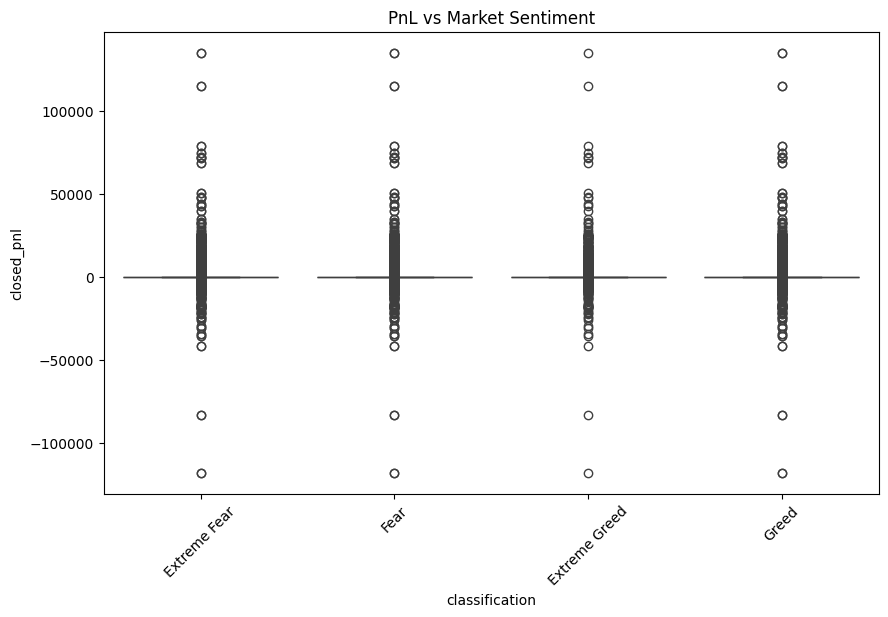

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='classification', y='closed_pnl', data=merged_df)
plt.title("PnL vs Market Sentiment")
plt.xticks(rotation=45)
plt.show()

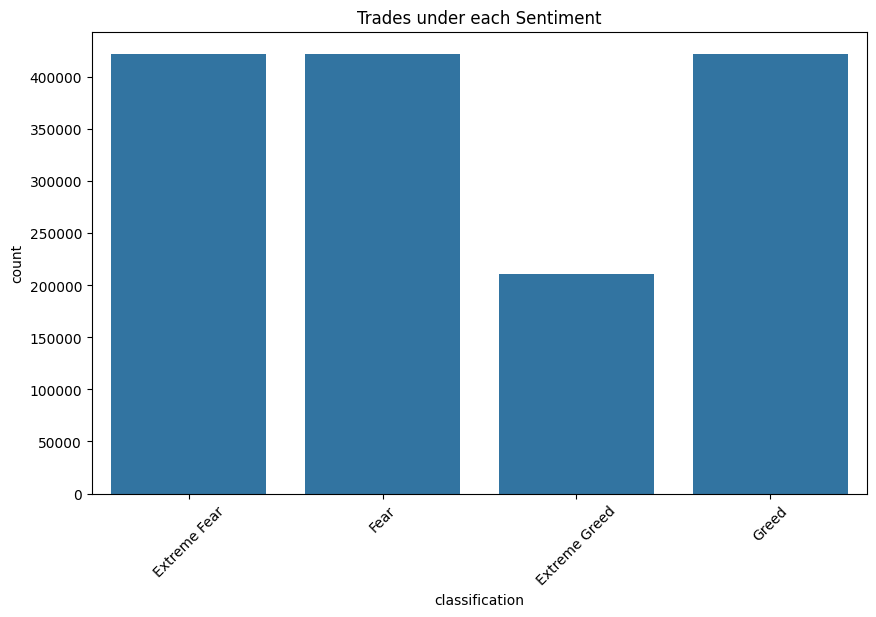

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(x='classification', data=merged_df)
plt.title("Trades under each Sentiment")
plt.xticks(rotation=45)
plt.show()

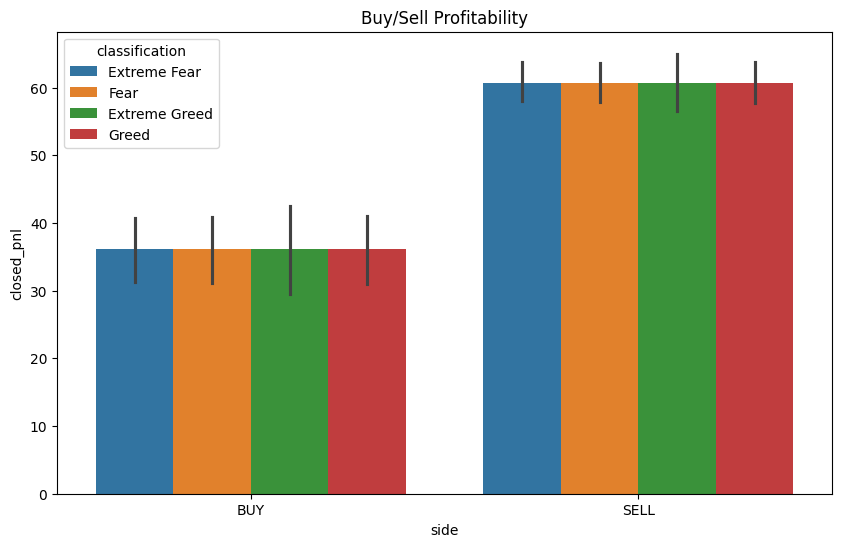

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(x='side', y='closed_pnl', hue='classification', data=merged_df)
plt.title("Buy/Sell Profitability")
plt.show()

In [17]:
merged_df.groupby('classification')['closed_pnl'].mean()

classification
Extreme Fear     48.749001
Extreme Greed    48.749001
Fear             48.749001
Greed            48.749001
Name: closed_pnl, dtype: float64

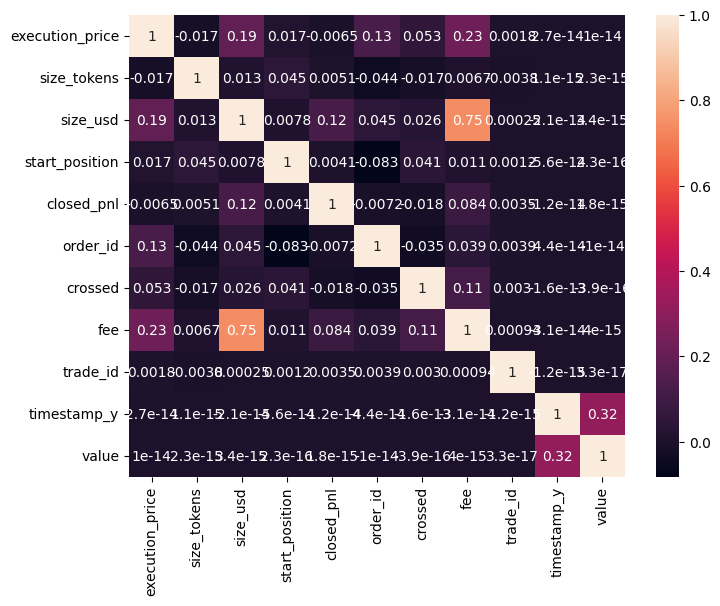

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(merged_df.corr(numeric_only=True), annot=True)
plt.show()

In [19]:
pd.crosstab(merged_df['classification'], merged_df['side'])

side,BUY,SELL
classification,,
Extreme Fear,205392,217056
Extreme Greed,102696,108528
Fear,205392,217056
Greed,205392,217056


In [20]:
merged_df.groupby('classification')['closed_pnl'].std()

classification
Extreme Fear     919.163740
Extreme Greed    919.164828
Fear             919.163740
Greed            919.163740
Name: closed_pnl, dtype: float64